In [22]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

In [3]:
insurance_data = pd.read_csv('../Linear_Regression/insurance.csv')
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]


X = pd.get_dummies(X, columns=['region'], drop_first=True, dtype=int)
X["sex"] = X["sex"].map({"female":0, "male":1})
X["smoker"] = X["smoker"].map(lambda s: 1 if s=="yes" else 0)

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,0,27.900,0,1,0,0,1,19,27.9
1,18,1,33.770,1,0,0,1,0,0,0.0
2,28,1,33.000,3,0,0,1,0,0,0.0
3,33,1,22.705,0,0,1,0,0,0,0.0
4,32,1,28.880,0,0,1,0,0,0,0.0


In [ ]:
lasso_model = Lasso(alpha=0.1) # alpha is the regularization strength
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 20921803.70


Alpha: 0.0001, Mean Squared Error: 20922607.13
Alpha: 0.001, Mean Squared Error: 20922599.87
Alpha: 0.01, Mean Squared Error: 20922527.33
Alpha: 0.1, Mean Squared Error: 20921803.70
Alpha: 0.5, Mean Squared Error: 20918648.89
Alpha: 0.8, Mean Squared Error: 20916337.80
Alpha: 1, Mean Squared Error: 20914832.64
Alpha: 2, Mean Squared Error: 20908106.78
Alpha: 3, Mean Squared Error: 20901927.93
Alpha: 4, Mean Squared Error: 20896130.81
Alpha: 5, Mean Squared Error: 20890881.00
Alpha: 10, Mean Squared Error: 20872844.79


<Axes: >

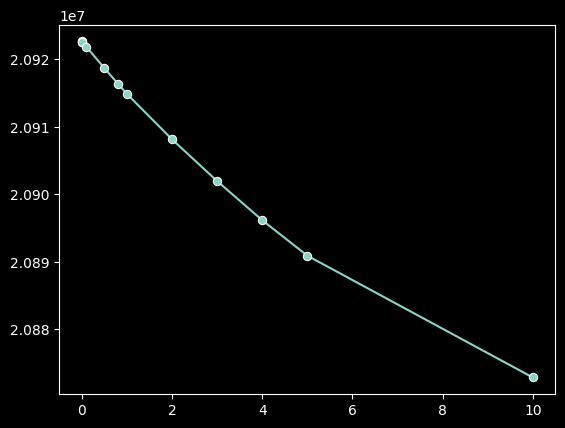

In [28]:
alphas = [0.0001, 0.001,0.01, 0.1, 0.5, 0.8, 1, 2, 3, 4, 5, 10]
mses = []
for alpha in alphas:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    print(f"Alpha: {alpha}, Mean Squared Error: {mse:.2f}")
sns.lineplot(x=alphas, y=mses, marker='o')

In [30]:
lasso_cv_model = LassoCV(
    alphas = alphas, cv=5,max_iter=1000, random_state=42
)
lasso_cv_model.fit(X_train, y_train)
print("Best alpha:", lasso_cv_model.alpha_)
y_pred_cv = lasso_cv_model.predict(X_test)
mse_cv = mean_squared_error(y_test, y_pred_cv)
r2 = r2_score(y_test, y_pred_cv)
print("Best MSE:", mse_cv)
print("Best R2:", r2)

Best alpha: 0.0001
Best MSE: 20922607.13101154
Best R2: 0.8652317031516601
